Zad. 9: Symuluj 1000 eksperymentów rzutu 20 monetami (p=0.5). Porównaj histogram wyników z
teoretycznym rozkładem dwumianowym B(20, 0.5).
Dataset:<br>
-Wygeneruj używając np.random.binomial()<br>
Wymagania:<br>
-Symulacja 1000 eksperymentów<br>
-Histogram wyników symulacji<br>
-Teoretyczny PMF rozkładu B(20, 0.5) nałożony na histogram<br>
-Porównanie średniej empirycznej z teoretyczną<br>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom #rozkład dwumianowy (PMF)

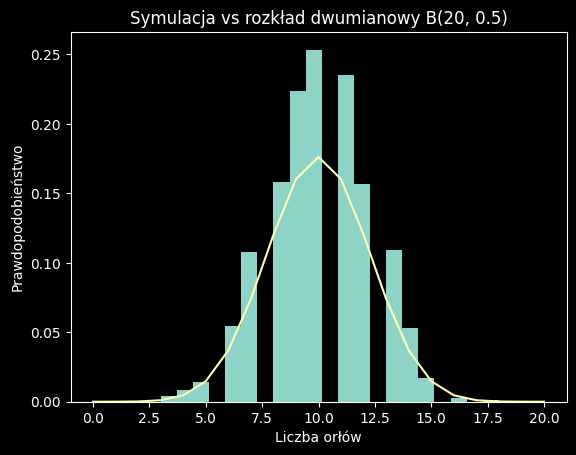

In [11]:
rzuty = 20
p = 0.5
l_experymentow = 1000

results = np.random.binomial(rzuty, p, l_experymentow)
results
#każda wartość to liczba orłów w 20 rzutach, dostajemy 1000 takich wyników

empirical_mean = np.mean(results) #śr. liczba orłów z symulacji
theoretical_mean = rzuty * p #śr. teoretyczna

x = np.arange(0, rzuty + 1) #mozliwe wart (0-20 orłów)
pmf = binom.pmf(x, rzuty, p) #prawdopodobienstwo sukcesów

plt.hist(results, bins=21, density=True) #kazdy bin to koszyk dla konkretnego wyniku 0-20; true to normalizacja, pokzaje prawdopodobienstwo a nie 1000 słupkow (histogram i pmf sa w tej samej skali)
plt.plot(x, pmf) #linia modelu
#histogram - rzeczywista symulacja
#linia - czysta teoria

plt.title("Symulacja vs rozkład dwumianowy B(20, 0.5)")
plt.xlabel("Liczba orłów")
plt.ylabel("Prawdopodobieństwo")
plt.show()

Zad. 10 : Dla datasetu Wine Quality zidentyfikuj outliery w kolumnie alcohol metodą z-score
(wartości > mean ± 3*std). Usuń outliery i porównaj statystyki przed/po.
Dataset:<br>
Wine Quality<br>
Wymagania:<br>
Oblicz z-scores<br>
Zidentyfikuj outliery (|z| > 3)<br>
Boxplot przed i po usunięciu<br>
Porównanie statystyk (mean, median, std)<br>

In [20]:
import pandas as pd
import numpy as np
from scipy.stats import zscore


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")
alcohol = df["alcohol"]
alcohol

z_scores = zscore(alcohol) #oblicza zscore dla kazdej obserwacji
outliers_mask = np.abs(z_scores) > 3 #ouliery; abs zamienia wszystkie wartośći na bezwzględne

n_outliers = outliers_mask.sum() #l. outlierów
n_outliers #8

df_clean = df[~outliers_mask]#~odwraca maskę, "usuwa" outliery - zostaje false, czyli <3

#statystyki przed usunięciem outlierów
mean_before = alcohol.mean()
median_before = alcohol.median()
std_before = alcohol.std()

#statystyki po usunięciu oulierów
mean_after = df_clean["alcohol"].mean()
median_after = df_clean["alcohol"].median()
std_after = df_clean["alcohol"].std()

stats_comparison = pd.DataFrame({
    "Before": [mean_before, median_before, std_before],
    "After": [mean_after, median_after, std_after]
}, index=["Mean", "Median", "Std"])

print("Liczba outlierów:", n_outliers)
print(stats_comparison)


Liczba outlierów: 8
           Before      After
Mean    10.422983  10.404431
Median  10.200000  10.100000
Std      1.065668   1.035413


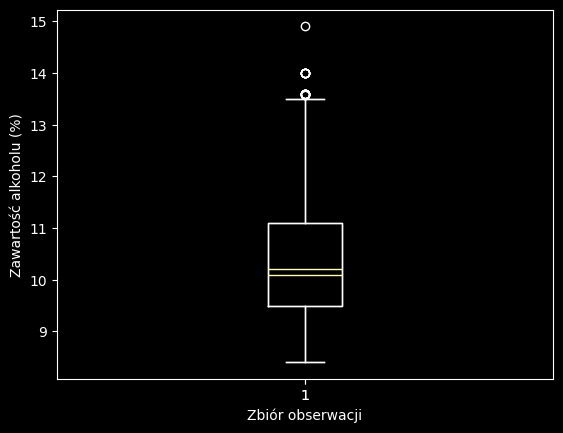

In [22]:
plt.boxplot(alcohol)
plt.boxplot(df_clean["alcohol"])
plt.xlabel("Zbiór obserwacji")
plt.ylabel("Zawartość alkoholu (%)")
plt.show()